In [5]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
import platform

In [16]:

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [7]:
filepath = './source/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv'
df = pd.read_csv(filepath, sep=',' , encoding='utf-8')
df.head()

/var/folders/qz/hyvszw9n4ms9wd1s5wn7fm2c0000gn/T/ipykernel_64686/1745599745.py:2: DtypeWarning: Columns (0: 층정보) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep=',' , encoding='utf-8')


,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
4,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715


In [9]:
df.shape

(537489, 39)

In [10]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='str')

In [11]:
set(df['상권업종대분류명'])

{'과학·기술', '교육', '보건의료', '부동산', '소매', '수리·개인', '숙박', '시설관리·임대', '예술·스포츠', '음식'}

In [13]:
print(set(df['상권업종중분류명']))

{'중식', '본사·경영 컨설팅', '유원지·오락', '기타 간이', '시설관리', '도서관·사적지', '일반 숙박', '주점', '일식', '기타 외국', '병원', '전문 디자인', '가정용품 대여', '섬유·의복·신발 소매', '오락용품 소매', '시계·귀금속 소매', '기타 교육', '모터사이클 소매', '이용·미용', '가전제품 수리', '일반 교육', '기타 전문 과학', '산업용품 대여', '기타 가정용품 수리', '컴퓨터 수리', '자동차 부품 소매', '식물 소매', '장례식장 ', '중고 상품 소매', '자동차 수리·세차', '여행사·보조', '교육 지원', '장식품 소매', '서양식', '통신장비 수리', '사무 지원', '연료 소매', '애완동물·용품 소매', '사진 촬영', '수의', '의약·화장품 소매', '회계·세무', '시장 조사', '고용 알선', '청소·방제', '종합 소매', '욕탕·신체관리', '세탁', '기타 보건', '식료품 소매', '안경·정밀기기 소매', '의원', '기타 개인', '스포츠 서비스', '가구 소매', '가전·통신 소매', '운송장비 대여', '법무관련 ', '담배 소매', '기타 숙박', '한식', '기타 생활용품 소매', '모터사이클 수리', '철물·건설자재 소매', '음료 소매', '기술 서비스', '비알코올 ', '동남아시아', '기타 사업 서비스', '구내식당·뷔페', '조경·유지', '부동산 서비스', '인쇄·제품제작', '광고', '기타 상품 소매'}


In [17]:
df.isnull().sum()

상가업소번호            0
상호명               0
지점명          490488
상권업종대분류코드         0
상권업종대분류명          0
상권업종중분류코드         0
상권업종중분류명          0
상권업종소분류코드         0
상권업종소분류명          0
표준산업분류코드        198
표준산업분류명         198
시도코드              0
시도명               0
시군구코드             0
시군구명              0
행정동코드             0
행정동명              0
법정동코드             0
법정동명              0
지번코드              0
대지구분코드            0
대지구분명             0
지번본번지            24
지번부번지         94482
지번주소              0
도로명코드             0
도로명               0
건물본번지             2
건물부번지        467846
건물관리번호         2272
건물명          286831
도로명주소             0
구우편번호             0
신우편번호             0
동정보          537489
층정보          200654
호정보          537489
경도                0
위도                0
dtype: int64

In [18]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='str')

In [19]:
# 시도명에서 '서울특별시'만 존재한다.
df['시도명'].unique()

<StringArray>
['서울특별시']
Length: 1, dtype: str

In [20]:
# 결측시를 시각화해서 볼 수 있다.
import missingno as msno

<Axes: >

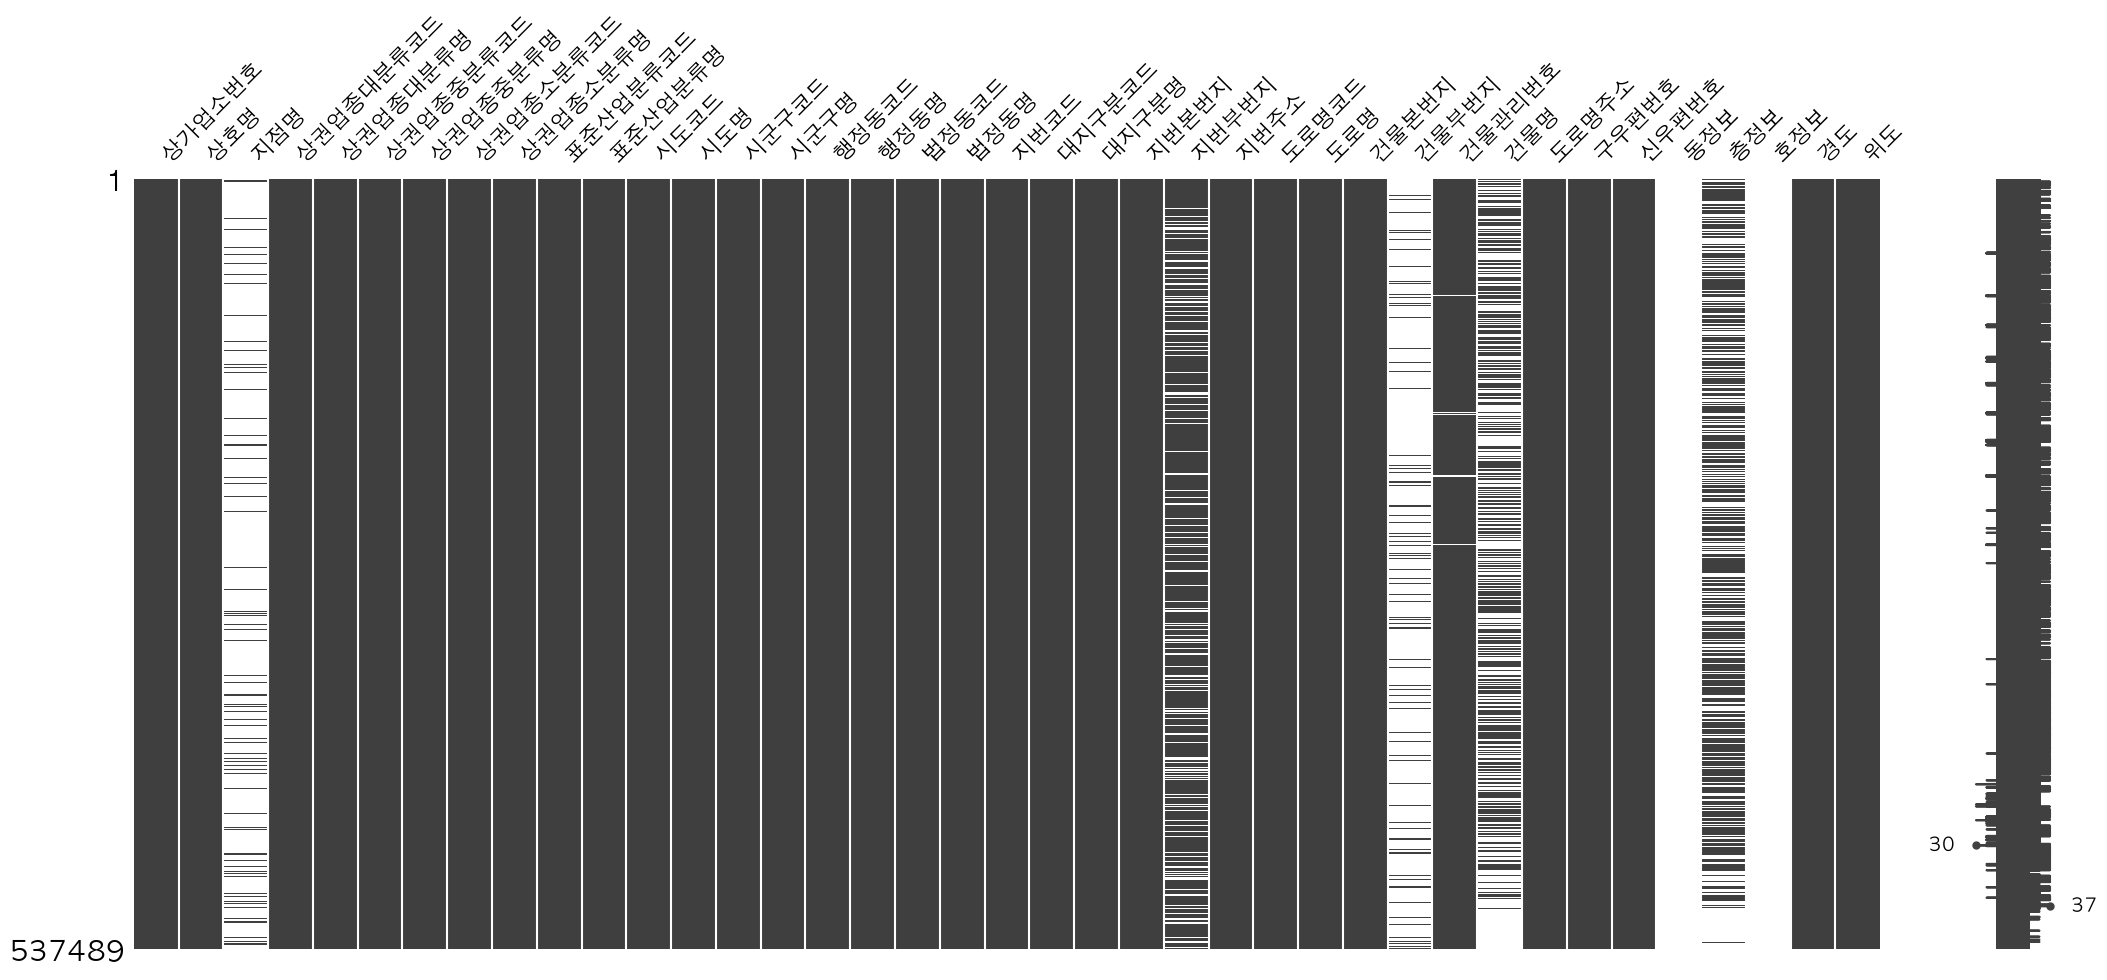

In [21]:
msno.matrix(df)

In [22]:
df['상권업종대분류명'].value_counts()

상권업종대분류명
음식         138558
소매         112810
과학·기술       92306
수리·개인       52039
교육          45080
부동산         24475
시설관리·임대     23812
예술·스포츠      20739
보건의료        18999
숙박           8671
Name: count, dtype: int64

In [23]:
df['상권업종중분류명'].value_counts()

상권업종중분류명
한식             53225
이용·미용          30997
섬유·의복·신발 소매    26895
기타 간이          26558
부동산 서비스        24475
               ...  
장례식장             478
모터사이클 소매         413
통신장비 수리          312
조경·유지            120
기타 외국             35
Name: count, Length: 75, dtype: int64

<Axes: xlabel='count', ylabel='상권업종대분류명'>

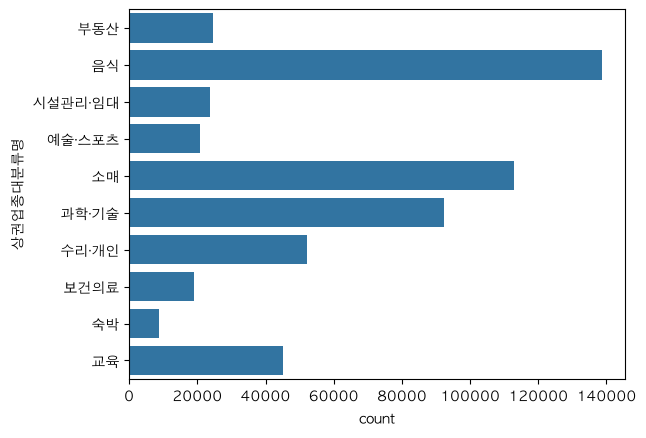

In [ ]:
sns.countplot(data=df, y='상권업종대분류명')

In [26]:
# df['상권업종대분류명'] == '음식'  vs df['상권업종대분류명'].str.contains('음식') 서로같다

df_food = df.loc[df['상권업종대분류명'].str.contains('음식')]
df_food.shape

(138558, 39)

In [27]:
df_food.head()

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
9,MA010120220809640417,솜노래팡팡,NaN,I2,음식,I211,주점,I21104,요리 주점,I56219,...,1165010800115770002022148,NaN,서울특별시 서초구 서초대로50길 75,137875,6650,NaN,1,NaN,127.013852,37.489862
25,MA010120220812811919,읏듬돈생삼겹살,NaN,I2,음식,I201,한식,I20107,돼지고기 구이/찜,I56113,...,1129013900103840023002884,NaN,서울특별시 성북구 화랑로40길 43,136817,2781,NaN,1,NaN,127.064015,37.613579
35,MA010120220806699845,유명숯불갈비,NaN,I2,음식,I201,한식,I20107,돼지고기 구이/찜,I56113,...,1150010300108390011020946,NaN,서울특별시 강서구 곰달래로 233,157902,7738,NaN,2,NaN,126.858861,37.531981


In [28]:
df_food['상권업종대분류명'].unique()

<StringArray>
['음식']
Length: 1, dtype: str

<Axes: xlabel='count', ylabel='상권업종중분류명'>

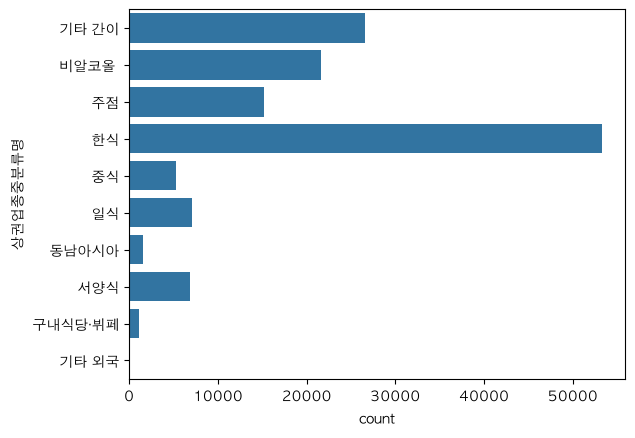

In [29]:
sns.countplot(data=df_food, y='상권업종중분류명')

이디야와 할리스

In [30]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='str')

In [32]:
dataset = df[['상호명', '지점명', '상권업종중분류명', '시도명', '시군구명', '행정동명', '도로명', '경도', '위도']]
dataset.head()

# print(dataset['상권업종중분류명'].unique())

# '비알코올'뒤에 공백이 있으므로 주의하세요
df_coffee = dataset[dataset['상권업종중분류명']=='비알코올 ']
df_coffee.head()

,상호명,지점명,상권업종중분류명,시도명,시군구명,행정동명,도로명,경도,위도
3,칸토빈,NaN,비알코올,서울특별시,강서구,공항동,서울특별시 강서구 방화동로,126.810493,37.563548
51,빽다방구산역점,NaN,비알코올,서울특별시,은평구,구산동,서울특별시 은평구 연서로,126.916688,37.610477
78,맹커피숍,NaN,비알코올,서울특별시,은평구,대조동,서울특별시 은평구 불광로,126.928818,37.610773
109,담다,NaN,비알코올,서울특별시,동대문구,용두동,서울특별시 동대문구 왕산로19가길,127.031631,37.581067
118,초원,NaN,비알코올,서울특별시,동대문구,신설동,서울특별시 동대문구 왕산로,127.024498,37.576284


In [33]:
df_coffee['상권업종중분류명'].unique()

<StringArray>
['비알코올 ']
Length: 1, dtype: str

In [34]:
print(df_coffee['상호명'])

3                    칸토빈
51               빽다방구산역점
78                  맹커피숍
109                   담다
118                   초원
               ...      
537363    스페이스맘(서원안길 합정)
537395        커피앳웍스 센터원점
537425      메이 베이크 커피베이킹
537437     메가엠지씨커피 논현동현점
537476       텐퍼센트커피 창동역점
Name: 상호명, Length: 21619, dtype: str


In [35]:
df_coffee['상호명'].value_counts()

상호명
투썸플레이스            70
메가엠지씨커피           63
이디야커피             57
이디야               57
컴포즈커피             43
                  ..
스페이스맘(서원안길 합정)     1
커피앳웍스 센터원점         1
메이 베이크 커피베이킹       1
메가엠지씨커피 논현동현점      1
텐퍼센트커피 창동역점        1
Name: count, Length: 19074, dtype: int64

In [36]:
print(sorted(list(set(df_coffee['상호명']))))

['(사)대한출판문화협회 송파분사무소', '(주)레스티카', '(주)스페이스제이피(바나프레소 그랑서울점)', '(주)예스엠컨설팅 탐앤탐스 군자역점', '(주)원준 / 메가엠지씨커피 목동호반써밋점', '(주)이테크건설산업 묵정동지점', '(주)큰손컴퍼니', '(주)파리크라상 커피앳웍스 경의선숲길점', '(주)파리크라상 파스쿠찌 김포공항 국제선점', '(주)파리크라상 파스쿠찌 서울대병원점', '(주)필스홀딩스 서초점(쿠지커피 교대역)', '(주)한국종합서비스_공차 한국종합기술사옥점', '(주)헤세드커피', '000케이크바', '0122 커피바(0122 coffee bar)', '0125커피바', '01팩토리', '09커피', '1%리버티커피', '1.5도씨', '100X커피', '101빌리지', '101스트릿노블레르점', '101커피', '101커피컨테이너', '101파트너스', '1059-3베이글커피하우스', '106길15', '10꼬르소꼬모', '10꼬르소꼬모카페', '10스퀘어남산', '10스퀘어오슬로회현', '11월', '120겹파이', '121호', '125수유', '132하우스', '139커피', '13포레스트', '1441카페로스터스', '14번가', '15아지트', '175도씨', '17도씨', '17번지넘버링', '18 메이 스트릿(18 May Street)', '1847카페', '193씨엠', '1980벽돌집', '1999커피', '1LL일', '1달러커피', '1인1잔', '1한가로이', '2.카페', '207', '208도씨', '208호', '210커피', '213점', '214베이커스트리트', '22그램', '237플랫폼카페', '24/7', '24CAFE33커피상왕십리역', '24시만화카페', '24시무인까페만월경병무청역점', '24시무인까페만월경서리풀점', '24시무인셀프카페', '24시무인셀프카페원효로점', '24시무인카페', '24시무인카페RO', '24시무인카페만월경', '24시무인카페만월경&음악연습실', '24시무인카페만월경노원

In [37]:
df_coffee[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA')].shape

(436, 9)

In [38]:
df_coffee[df_coffee['상호명'].str.contains('할리스|hollys|HOLLYS')].shape

(114, 9)

In [39]:
df_coffee.loc[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA'), '상호명'].unique()

<StringArray>
[        '이디야커피',        '이디야성산점',        '이디야강서점',           '이디야',
        '이디야커피숍',        '이디야포이점',    '이디야연신내통일로점',         '이디야삼성',
          '이디야주',     '이디야커피길동역점',
 ...
 '이디야 왕십리비트플렉스점',       '이디야 갈현점',     '이디야 자양문원점',      '이디야용산원효점',
    '이디야커피 먹골역점',      '이디야청량리역점',    '이디야커피르피에드점',       '이디야대방역점',
       '이디야상계동점',   '이디야커피 염창대로점']
Length: 315, dtype: str

In [40]:
df_coffee.loc[df_coffee['상호명'].str.contains('할리스|hollys|HOLLYS'),'상호명'].unique()

<StringArray>
[         '할리스커피이수역점',            '할리스신림역점',           '할리스커피수서점',
        '할리스가산디지털단지점',          '할리스커피홍대역점', '모닝에프디(할리스커피노량진역점)주',
        '할리스커피테크노마트점',       '할리스커피구로거리공원점',         '할리스커피홍대역2번',
            '할리스커피남부',                '할리스',         '할리스고덕리엔파크점',
          '할리스청담삼성로점',              '할리스커피',            '할리스커피난곡',
      '할리스커피백석예술대학교점',        '할리스커피강남대로논현',         '할리스커피충정래미안',
    '할리스커피구로디지털뉴스테이점',        '할리스커피굽은다리역점',     '할리스커피선유도역점TS카페',
            '할리스대방역점',           '할리스샹제리제점',             '할리스도심2',
         '할리스커피수락산역점',     '서울고무상사할리스종로5가점',          '할리스커피구로역점',
          '할리스고덕그라시움',           '할리스독립문역점',         '케이지할리스에프앤비',
            '할리스커피도심',            '할리스개화산점',          '할리스엘지리테일주',
              '할리스시흥',              '할리스숙대',            '할리스노원역점',
           '할리스가산대륭2',            '할리스강변역점',            '할리스등촌역점',
          '할리스서서울공원점',           '할리스메리츠봉래',          '할리스여의도포스트',
           '할리스오목교역점',              '할리스2점',    

In [41]:
# 이디야와 할리스 데이터 가져오기
df_coffee_edi_holly =  df_coffee.loc[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA|할리스|hollys|HOLLYS')].copy()
df_coffee_edi_holly.shape

(550, 9)

In [42]:
df_coffee_edi_holly.sample(5)

,상호명,지점명,상권업종중분류명,시도명,시군구명,행정동명,도로명,경도,위도
183057,이디야,NaN,비알코올,서울특별시,강남구,역삼1동,서울특별시 강남구 테헤란로4길,127.030069,37.495544
238973,이디야커피회기,중앙점,비알코올,서울특별시,동대문구,휘경1동,서울특별시 동대문구 회기로,127.057451,37.590184
526401,이디야커피광흥창역점,NaN,비알코올,서울특별시,마포구,서강동,서울특별시 마포구 서강로,126.931617,37.547201
179035,할리스커피,NaN,비알코올,서울특별시,관악구,낙성대동,서울특별시 관악구 관악로,126.952944,37.480519
83946,이디야커피신림패션,문화점,비알코올,서울특별시,관악구,신림동,서울특별시 관악구 봉천로6길,126.925429,37.488623


In [44]:
# 상호명에 이디야가 포함된 것에 브랜드명 컬럼명을 추가하고 '이디야'을 저장한다.
df_coffee_edi_holly.loc[df_coffee_edi_holly['상호명'].str.contains('이디야|ediya|EDIYA'),'브랜드명'] ='이디야'

In [45]:
df_coffee_edi_holly.loc[df_coffee_edi_holly['상호명'].str.contains('할리스|hollys|HOLLYS'), '브랜드명'] = '할리스'

In [46]:
df_coffee_edi_holly.sample(5)

,상호명,지점명,상권업종중분류명,시도명,시군구명,행정동명,도로명,경도,위도,브랜드명
116521,이디야커피내방역점,NaN,비알코올,서울특별시,서초구,방배1동,서울특별시 서초구 서초대로,126.994199,37.487520,이디야
486238,할리스커피배명,사거리점,비알코올,서울특별시,송파구,석촌동,서울특별시 송파구 백제고분로,127.097340,37.502779,할리스
267583,이디야,잠실점,비알코올,서울특별시,송파구,잠실3동,서울특별시 송파구 송파대로,127.093055,37.513135,이디야
496581,할리스커피용산더프라임점,NaN,비알코올,서울특별시,용산구,원효로1동,서울특별시 용산구 원효로90길,126.969721,37.540396,할리스
505138,이디야커피대림1동점,NaN,비알코올,서울특별시,영등포구,대림1동,서울특별시 영등포구 도림로,126.902827,37.496436,이디야


In [47]:
df_coffee_edi_holly['브랜드명'].unique()

<StringArray>
['이디야', '할리스']
Length: 2, dtype: str

In [48]:
df_coffee_edi_holly['브랜드명'].value_counts()

브랜드명
이디야    436
할리스    114
Name: count, dtype: int64

In [49]:
geo_df_coffee =  df_coffee_edi_holly.copy()

In [50]:
import folium

In [51]:
folium.Map

folium.folium.Map

In [52]:
map = folium.Map(location=[geo_df_coffee['위도'].mean(), geo_df_coffee['경도'].mean()],
           zoom_start=12, tiles='OpenStreetMap')  # tiles='OpenStreetMap'


for n in geo_df_coffee.index:
  #팝업에 들어갈 텍스트를 지정해 준다.
  popup_name=geo_df_coffee.loc[n,'상호명'] + ' - '\
  +geo_df_coffee.loc[n, '도로명']

  if geo_df_coffee.loc[n,'브랜드명']=='이디야':
    icon_color='blue'
  else:
    icon_color='red'

  folium.CircleMarker(
      location=[geo_df_coffee.loc[n, '위도'],geo_df_coffee.loc[n,'경도']],
      radius = 3,
      popup =popup_name,
      color = icon_color,
      fill=True,
      fill_color=icon_color
  ).add_to(map)


In [53]:
map